Using device: cuda
Total samples loaded: 34159
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'Space' 'Stop' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Epoch [1/20] Train Acc: 0.9014 | Test Acc: 0.9999
Epoch [2/20] Train Acc: 0.9935 | Test Acc: 0.9998
Epoch [3/20] Train Acc: 0.9940 | Test Acc: 1.0000
Epoch [4/20] Train Acc: 0.9963 | Test Acc: 0.9987
Epoch [5/20] Train Acc: 0.9959 | Test Acc: 1.0000
Epoch [6/20] Train Acc: 0.9960 | Test Acc: 1.0000
Epoch [7/20] Train Acc: 0.9957 | Test Acc: 1.0000
Epoch [8/20] Train Acc: 0.9970 | Test Acc: 1.0000
Epoch [9/20] Train Acc: 0.9973 | Test Acc: 1.0000
Epoch [10/20] Train Acc: 0.9964 | Test Acc: 0.9992
Epoch [11/20] Train Acc: 0.9983 | Test Acc: 1.0000
Epoch [12/20] Train Acc: 0.9965 | Test Acc: 1.0000
Epoch [13/20] Train Acc: 0.9959 | Test Acc: 1.0000
Epoch [14/20] Train Acc: 0.9989 | Test Acc: 1.0000
Epoch [15/20] Train Acc: 0.9981 | Test Acc: 1.0000
Epoch [16/20] Train Acc: 0.9977 | Test Acc: 1.0000
Epoch [17/20] T

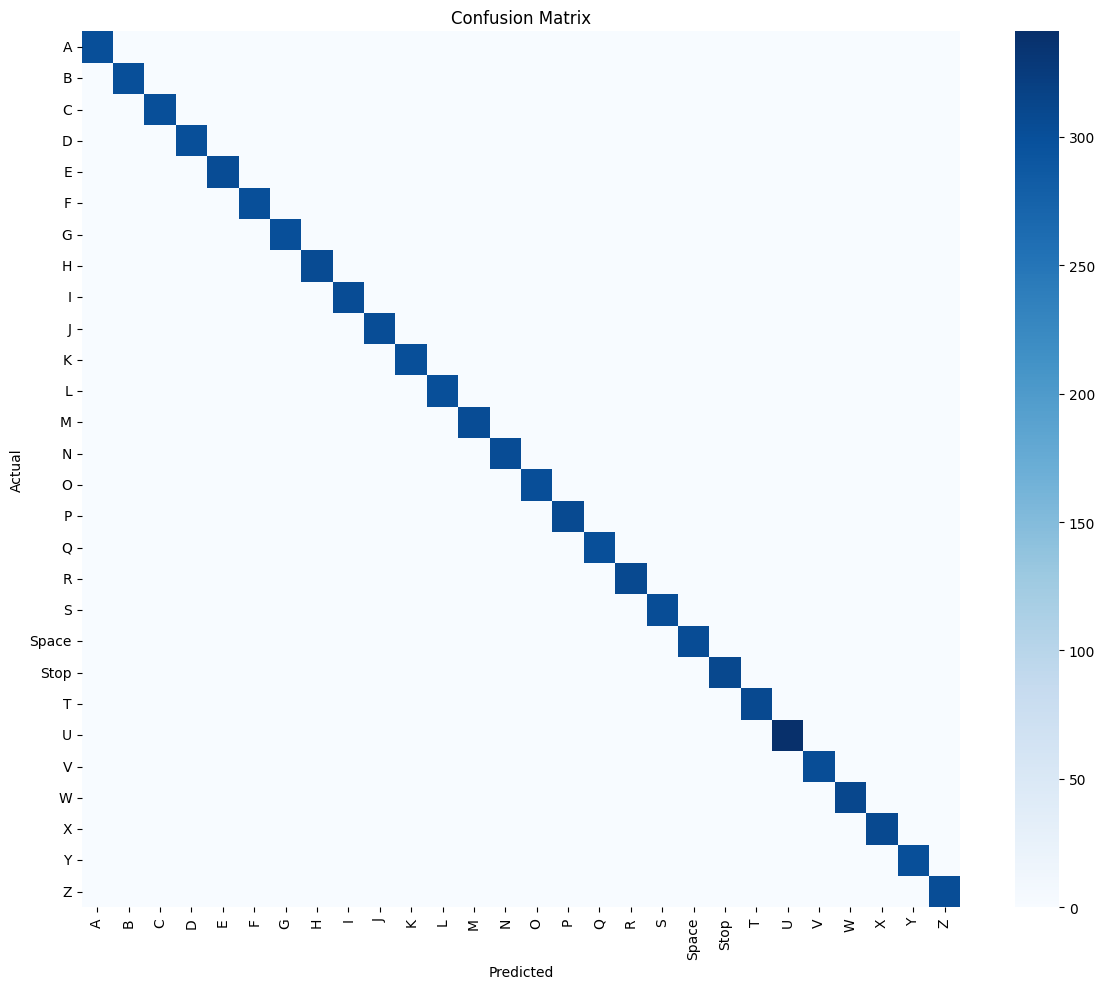

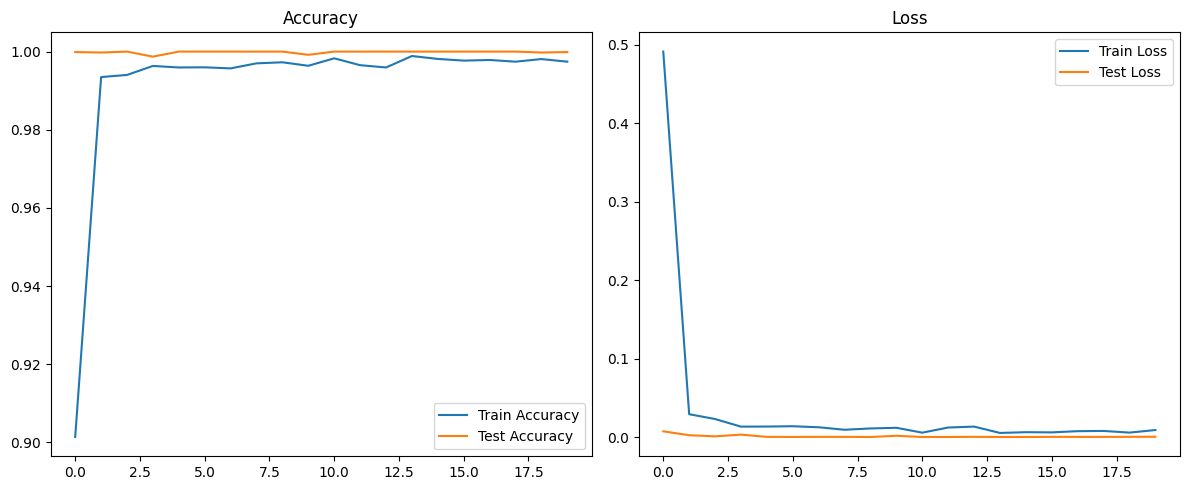


Training Complete. Model and metrics saved.


In [ ]:
import os
import json
import joblib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# ================== CONFIG ==================
DATASET_DIR = r"D:\Projects\Capstone Project\Vision based hand sign detection & classification usig DL models\datasets\custom\Raw Pixel , Landmarks & Yolo\ASL Normalized Hand Landmarks-1"

SAVE_DIR = r"D:"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 20
LR = 0.001
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ================== LOAD DATA ==================
X = []
y = []

class_names = sorted(os.listdir(DATASET_DIR))

for class_name in class_names:
    class_path = os.path.join(DATASET_DIR, class_name, "landmarks")

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)
            landmarks = np.load(file_path)

            if landmarks.shape[0] == 63:
                X.append(landmarks.astype(np.float32))
                y.append(class_name)

X = np.array(X)
y = np.array(y)

print("Total samples loaded:", len(X))

# ================== ENCODE LABELS ==================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_)

joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# ================== SPLIT DATA ==================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# ================== DATASET CLASS ==================
class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    LandmarkDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    LandmarkDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ================== MODEL ==================
class ASL_MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = ASL_MLP(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ================== TRAIN LOOP ==================
best_acc = 0.0
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    test_correct = 0
    test_total = 0
    test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = test_correct / test_total
    test_loss /= len(test_loader)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model.state_dict(),
            os.path.join(SAVE_DIR, "asl_landmark_mlp_best.pth")
        )

print("\nBest Test Accuracy:", best_acc)

# ================== METRICS ==================
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_
))

# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm,
            annot=False,
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
plt.show()

# ================== ACCURACY & LOSS GRAPHS ==================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"))
plt.show()

# ================== SAVE CONFIG ==================
config = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "num_classes": NUM_CLASSES,
    "best_accuracy": best_acc,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

with open(os.path.join(SAVE_DIR, "training_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("\nTraining Complete. Model and metrics saved.")

Using device: cuda
Found 59802 .npy files
Total samples loaded: 59802
Unique classes before filtering: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'label' 'space']

Class distribution:
  A: 2086 samples
  B: 2152 samples
  C: 1796 samples
  D: 2300 samples
  E: 2202 samples
  F: 2767 samples
  G: 2291 samples
  H: 2297 samples
  I: 2272 samples
  J: 2435 samples
  K: 2598 samples
  L: 2419 samples
  M: 1183 samples
  N: 996 samples
  O: 2161 samples
  P: 1923 samples
  Q: 1957 samples
  R: 2435 samples
  S: 2435 samples
  T: 2262 samples
  U: 2452 samples
  V: 2490 samples
  W: 2403 samples
  X: 2075 samples
  Y: 2524 samples
  Z: 2248 samples
  del: 1425 samples
  label: 1 samples
  space: 1217 samples

Classes with at least 2 samples: 28
Samples after filtering: 59801
Classes after filtering: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']

⚠️  

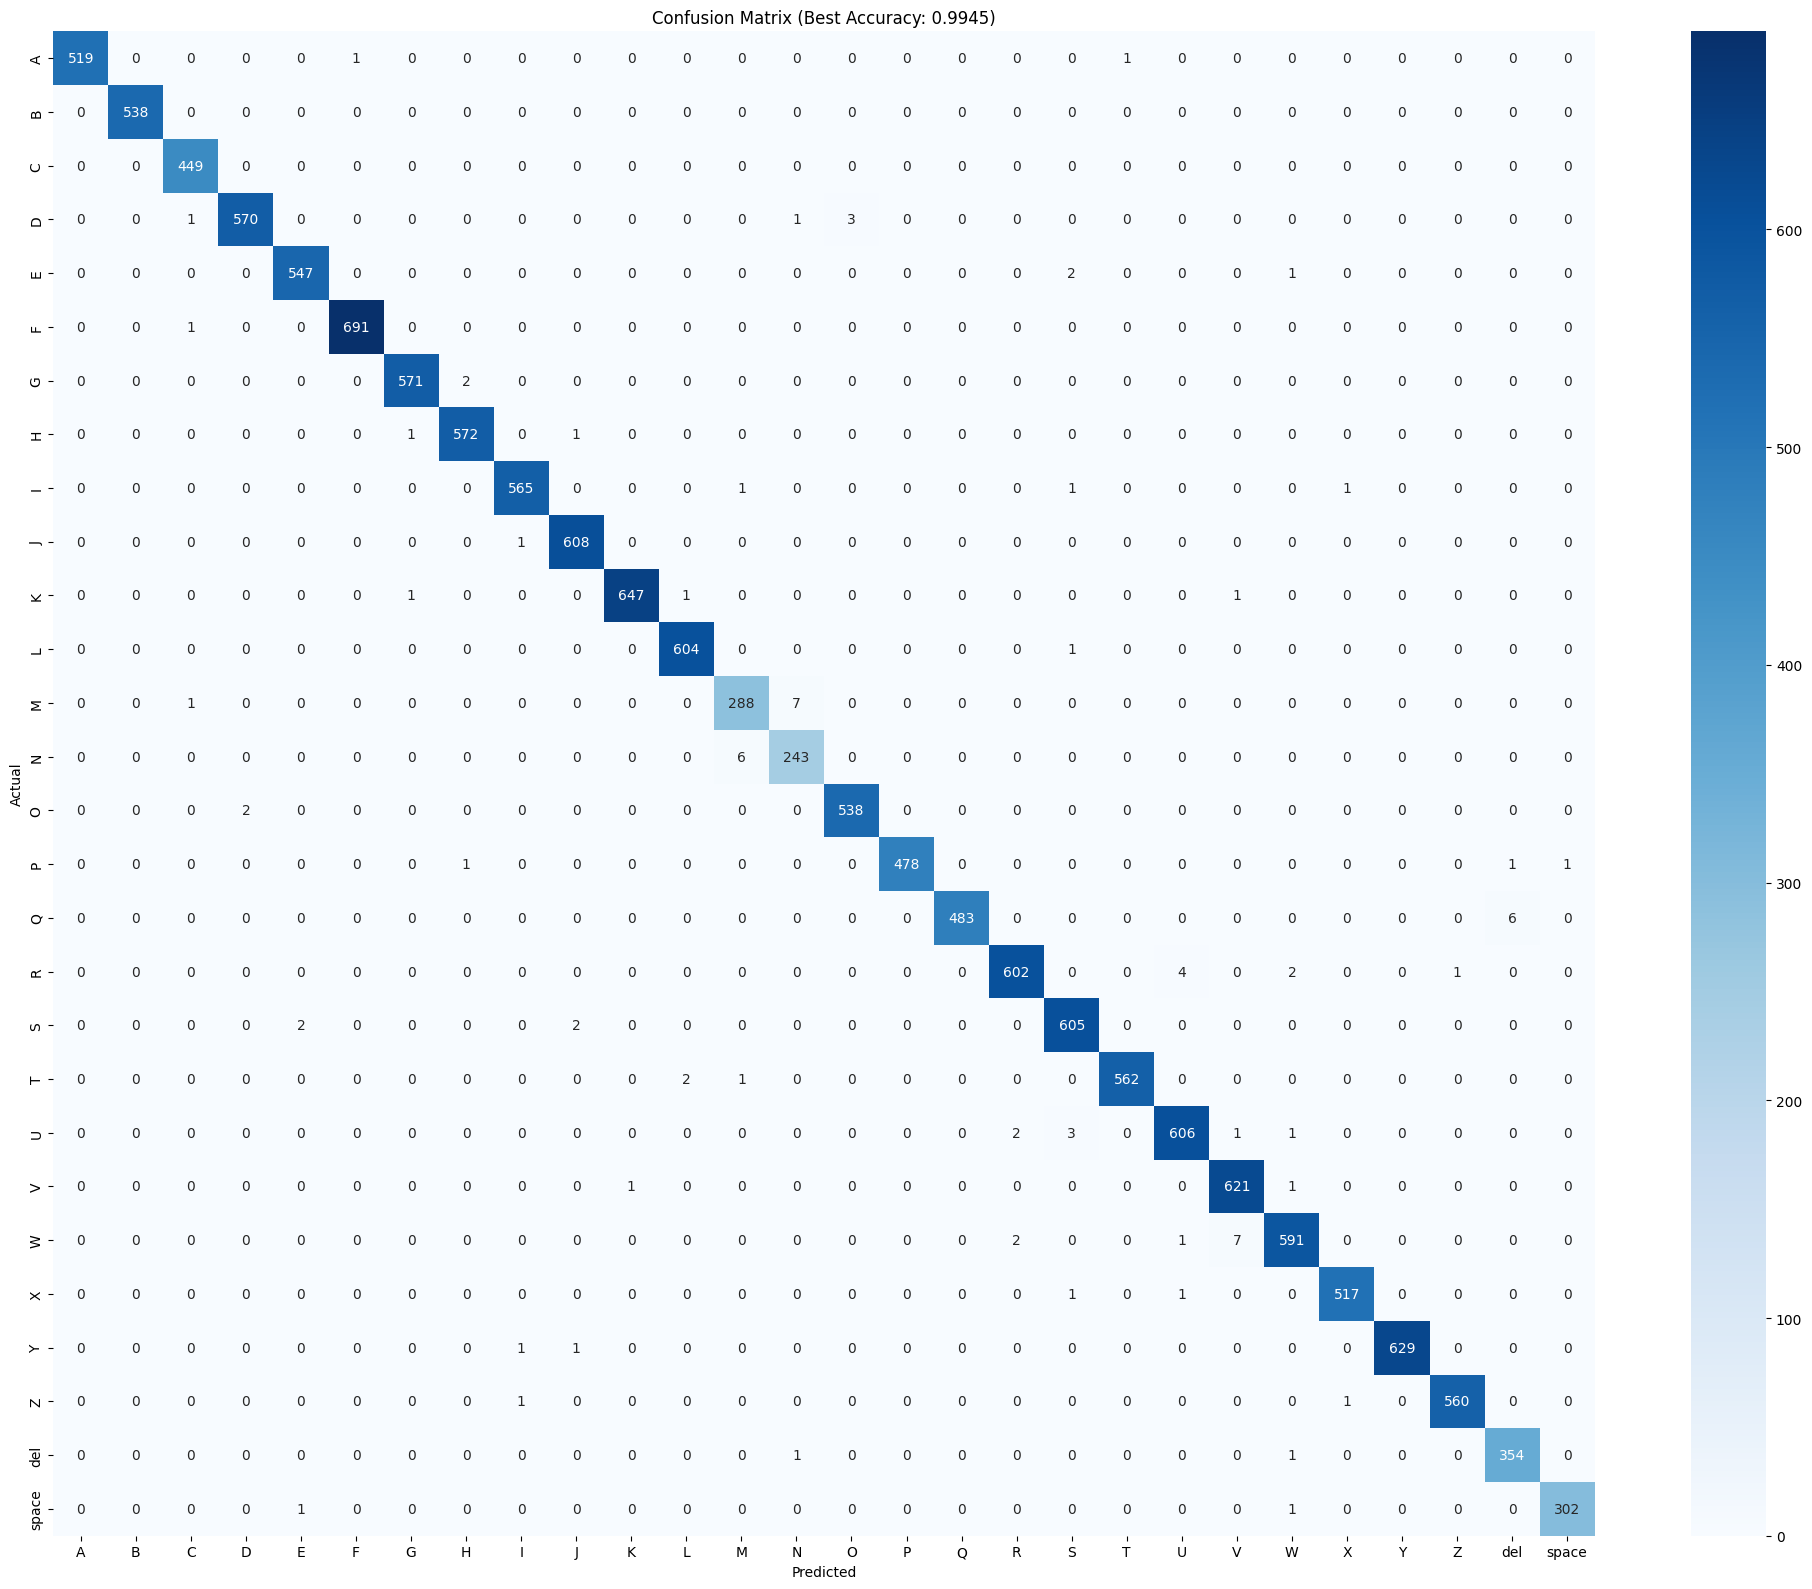

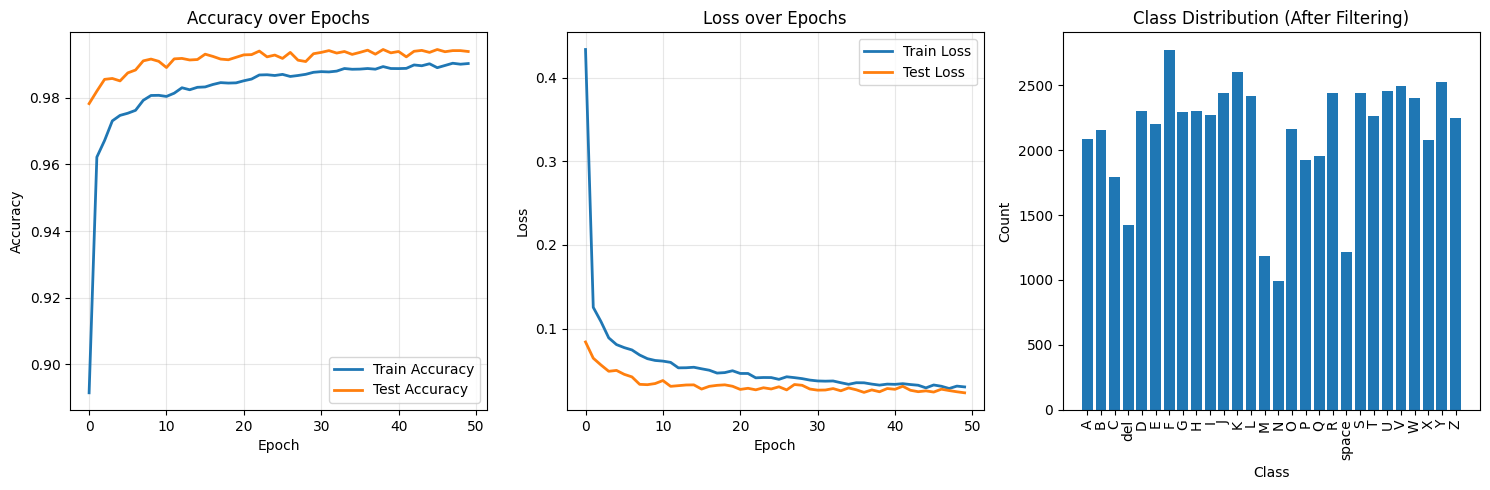


✅ Training Complete!
📁 All files saved to: D:/Projects/Capstone Project/Vision based hand sign detection & classification usig DL models/runs/hand_landmark_MLP_pipeline_Normalized-1
📊 Best Accuracy: 0.9945
🎯 Final F1 Score: 0.9939


In [1]:
import os
import json
import joblib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# ================== CONFIG ==================
DATASET_DIR = r"D:/dataset/landmarks"  # Your new folder with all .npy files

SAVE_DIR = r"D:/Projects/Capstone Project/Vision based hand sign detection & classification usig DL models/runs/hand_landmark_MLP_pipeline_Normalized-1"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 50
LR = 0.001
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ================== LOAD DATA ==================
X = []
y = []

# Get all .npy files
all_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.npy')]
print(f"Found {len(all_files)} .npy files")

for filename in all_files:
    file_path = os.path.join(DATASET_DIR, filename)
    
    # Extract class name from filename (e.g., "R_001.npy" -> "R")
    class_name = filename.split('_')[0]
    
    # Load landmarks
    landmarks = np.load(file_path)
    
    if landmarks.shape[0] == 63:  # Ensure correct shape
        X.append(landmarks.astype(np.float32))
        y.append(class_name)

X = np.array(X)
y = np.array(y)

print("Total samples loaded:", len(X))
print("Unique classes before filtering:", np.unique(y))

# ================== CHECK CLASS DISTRIBUTION ==================
class_counts = Counter(y)
print("\nClass distribution:")
for class_name, count in sorted(class_counts.items()):
    print(f"  {class_name}: {count} samples")

# ================== FILTER OUT CLASSES WITH < 2 SAMPLES ==================
min_samples_per_class = 2
valid_classes = [cls for cls, count in class_counts.items() if count >= min_samples_per_class]
print(f"\nClasses with at least {min_samples_per_class} samples: {len(valid_classes)}")

# Filter the data
mask = np.isin(y, valid_classes)
X_filtered = X[mask]
y_filtered = y[mask]

print(f"Samples after filtering: {len(X_filtered)}")
print(f"Classes after filtering: {np.unique(y_filtered)}")

# If too many classes were removed, you might want to adjust
if len(valid_classes) < len(class_counts):
    removed_classes = set(class_counts.keys()) - set(valid_classes)
    print(f"\n⚠️  Removed classes with < {min_samples_per_class} samples: {removed_classes}")

# ================== ENCODE LABELS ==================
le = LabelEncoder()
y_encoded = le.fit_transform(y_filtered)

NUM_CLASSES = len(le.classes_)
print(f"\nNumber of classes for training: {NUM_CLASSES}")
print("Classes:", le.classes_)

joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# ================== SPLIT DATA ==================
# Check if we can use stratify (need at least 2 samples per class in each split)
min_class_size = min(Counter(y_encoded).values())
print(f"\nMinimum class size after encoding: {min_class_size}")

if min_class_size < 2:
    print("⚠️  Some classes still have only 1 sample. Using train_test_split without stratify.")
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_encoded,
        test_size=0.25,
        random_state=42,
        stratify=None  # No stratification
    )
else:
    print("✓ Using stratified split")
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered, y_encoded,
        test_size=0.25,
        random_state=42,
        stratify=y_encoded
    )

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Check class distribution in train/test
print("\nClass distribution in training set:")
train_counts = Counter(y_train)
for class_idx, count in sorted(train_counts.items()):
    print(f"  {le.classes_[class_idx]}: {count}")

print("\nClass distribution in testing set:")
test_counts = Counter(y_test)
for class_idx, count in sorted(test_counts.items()):
    print(f"  {le.classes_[class_idx]}: {count}")

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# ================== DATASET CLASS ==================
class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    LandmarkDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    LandmarkDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ================== MODEL ==================
class ASL_MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = ASL_MLP(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ================== TRAIN LOOP ==================
best_acc = 0.0
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

# Initialize lists for final metrics
all_preds_final = []
all_labels_final = []

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    test_correct = 0
    test_total = 0
    test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = test_correct / test_total
    test_loss /= len(test_loader)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    # Store predictions from last epoch for final metrics
    if epoch == EPOCHS - 1:
        all_preds_final = all_preds
        all_labels_final = all_labels

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model.state_dict(),
            os.path.join(SAVE_DIR, "asl_landmark_mlp_best.pth")
        )
        print(f"  -> New best model saved! Accuracy: {best_acc:.4f}")

print("\nBest Test Accuracy:", best_acc)

# ================== METRICS ==================
# Use predictions from the last epoch
precision = precision_score(all_labels_final, all_preds_final, average='weighted', zero_division=0)
recall = recall_score(all_labels_final, all_preds_final, average='weighted', zero_division=0)
f1 = f1_score(all_labels_final, all_preds_final, average='weighted', zero_division=0)

print("\nPrecision (weighted):", precision)
print("Recall (weighted):", recall)
print("F1 Score (weighted):", f1)

# Per-class metrics
print("\nClassification Report:\n")
print(classification_report(
    all_labels_final,
    all_preds_final,
    target_names=le.classes_,
    zero_division=0
))

# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(all_labels_final, all_preds_final)

plt.figure(figsize=(20, 16))  # Larger figure for many classes
sns.heatmap(cm,
            annot=True,  # Show numbers
            fmt='d',     # Integer format
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Best Accuracy: {best_acc:.4f})")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

# ================== ACCURACY & LOSS GRAPHS ==================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_acc_list, label="Train Accuracy", linewidth=2)
plt.plot(test_acc_list, label="Test Accuracy", linewidth=2)
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(train_loss_list, label="Train Loss", linewidth=2)
plt.plot(test_loss_list, label="Test Loss", linewidth=2)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Class distribution
plt.subplot(1, 3, 3)
class_counts_filtered = Counter(y_filtered)
plt.bar(class_counts_filtered.keys(), class_counts_filtered.values())
plt.title("Class Distribution (After Filtering)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

# ================== SAVE CONFIG ==================
config = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "num_classes": NUM_CLASSES,
    "num_samples_original": len(X),
    "num_samples_filtered": len(X_filtered),
    "num_train_samples": len(X_train),
    "num_test_samples": len(X_test),
    "best_accuracy": best_acc,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_score_weighted": f1,
    "classes": le.classes_.tolist(),
    "class_distribution": {str(k): v for k, v in class_counts_filtered.items()},
    "removed_classes": list(set(class_counts.keys()) - set(valid_classes)) if 'valid_classes' in locals() else []
}

with open(os.path.join(SAVE_DIR, "training_config.json"), "w") as f:
    json.dump(config, f, indent=4)

# Save the final model
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_acc': best_acc,
    'config': config
}, os.path.join(SAVE_DIR, "asl_landmark_mlp_final.pth"))

print("\n✅ Training Complete!")
print(f"📁 All files saved to: {SAVE_DIR}")
print(f"📊 Best Accuracy: {best_acc:.4f}")
print(f"🎯 Final F1 Score: {f1:.4f}")